# **Problem Statement**

The aim of this project is to develop a machine learning model that accurately classifies loan applicants into different credit risk categories using historical financial and borrower information, such as income, employment length, home ownership, loan amount, interest rate, previous default history, and credit history. The model predicts the likelihood of loan default, enabling financial institutions to assess credit risk, reduce financial losses, and make informed, data-driven lending decisions.

**Column Descriptions:**

- ID: Unique identifier for each loan applicant.
- Age: Age of the loan applicant.
- Income: Income of the loan applicant.
- Home: Home ownership status (Own, Mortgage, Rent).
- Emp_Length: Employment length in years.
- Intent: Purpose of the loan (e.g., education, home improvement).
- Amount: Loan amount applied for.
- Rate: Interest rate on the loan.
- Status: Loan approval status (Fully Paid, Charged Off, Current).
- Percent_Income: Loan amount as a percentage of income.
- Default: Whether the applicant has defaulted on a loan previously (Yes, No).
- Cred_Length: Length of the applicant's credit history.

In [1]:
import sklearn
print(sklearn.__version__)

1.6.1


In [2]:
# import the libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
import sklearn


In [3]:
# Load the data
df = pd.read_csv("/content/credit_risk.csv")
df.head()

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4


# **Data Exploration**

In [4]:
# dimension of the data
df.shape

(32581, 12)

In [5]:
# Basic description of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              32581 non-null  int64  
 1   Age             32581 non-null  int64  
 2   Income          32581 non-null  int64  
 3   Home            32581 non-null  object 
 4   Emp_length      31686 non-null  float64
 5   Intent          32581 non-null  object 
 6   Amount          32581 non-null  int64  
 7   Rate            29465 non-null  float64
 8   Status          32581 non-null  int64  
 9   Percent_income  32581 non-null  float64
 10  Default         32581 non-null  object 
 11  Cred_length     32581 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 3.0+ MB


The data consisit of 9 Numerical and 3 Categorical features.

In [6]:
# check for null values
(df.isnull().sum() / len(df)) *100

,0
Id,0.000000
Age,0.000000
Income,0.000000
Home,0.000000
Emp_length,2.747000
Intent,0.000000
Amount,0.000000
Rate,9.563856
Status,0.000000
Percent_income,0.000000


In [7]:
# statical info of numerical columns
df.describe()

,Id,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length
count,32581.000000,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,16290.006139,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,9405.479594,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,0.000000,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,8145.000000,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,16290.000000,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,24435.000000,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,32780.000000,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
# check for duplicate values
df.duplicated().sum()

np.int64(0)

The dataset does not contain any duplicates

In [9]:
# let's drop the id column
df = df.drop(columns='Id')

In [10]:
df['Home'] = df['Home'].replace({"RENT": "Rent",
                                 "OWN": "Own",
                                 "MORTGAGE": "Mortgage",
                                 "OTHER": "Other"})

# verify
print(df['Home'].value_counts())

Home
Rent        16446
Mortgage    13444
Own          2584
Other         107
Name: count, dtype: int64


In [11]:
df['Intent'] = df['Intent'].replace({
    "PERSONAL": "Personal",
    "EDUCATION": "Education",
    "MEDICAL": "Medical",
    "VENTURE": "Venture",
    "DEBTCONSOLIDATION": "Debt Consolidation",
    "HOMEIMPROVEMENT": "Home Improvement"
})

# Verify
print(df['Intent'].value_counts())

Intent
Education             6453
Medical               6071
Venture               5719
Personal              5521
Debt Consolidation    5212
Home Improvement      3605
Name: count, dtype: int64


In [12]:
df['Default'] = df['Default'].replace({'N': 'No', 'Y': 'Yes'})

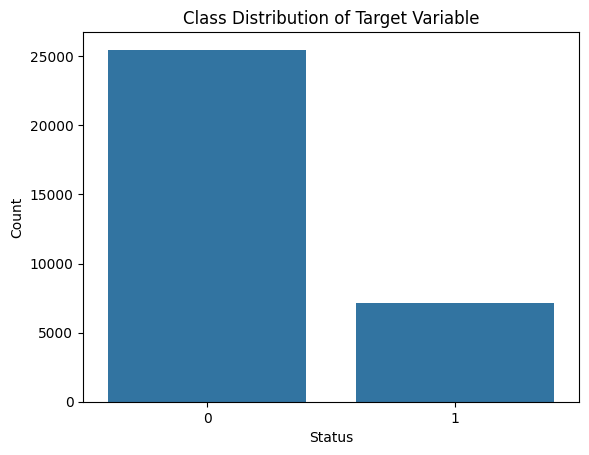

In [13]:
# Status Distribution
sns.countplot(data = df, x = 'Status')
plt.title("Class Distribution of Target Variable")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [14]:
print(df['Status'].value_counts(normalize = True)*100)

Status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


In [15]:
# Numerical features
num_features = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical features
cat_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", num_features)
print("Categorical Features:", cat_features)

Numerical Features: Index(['Age', 'Income', 'Emp_length', 'Amount', 'Rate', 'Status',
       'Percent_income', 'Cred_length'],
      dtype='object')
Categorical Features: Index(['Home', 'Intent', 'Default'], dtype='object')


In [16]:
for col in num_features:
    print(f"{col}: {df[col].nunique()} unique values")

Age: 58 unique values
Income: 4295 unique values
Emp_length: 36 unique values
Amount: 753 unique values
Rate: 348 unique values
Status: 2 unique values
Percent_income: 77 unique values
Cred_length: 29 unique values


In [17]:
df['Emp_length'] = df['Emp_length'].fillna(df['Emp_length'].median())

In [18]:
df['Rate'] = df['Rate'].fillna(df['Rate'].median())

In [19]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
df.head()

,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,22,59000,Rent,123.0,Personal,35000,16.02,1,0.59,Yes,3
1,21,9600,Own,5.0,Education,1000,11.14,0,0.10,No,2
2,25,9600,Mortgage,1.0,Medical,5500,12.87,1,0.57,No,3
3,23,65500,Rent,4.0,Medical,35000,15.23,1,0.53,No,2
4,24,54400,Rent,8.0,Medical,35000,14.27,1,0.55,Yes,4


# **Exploratory Data Analysis**

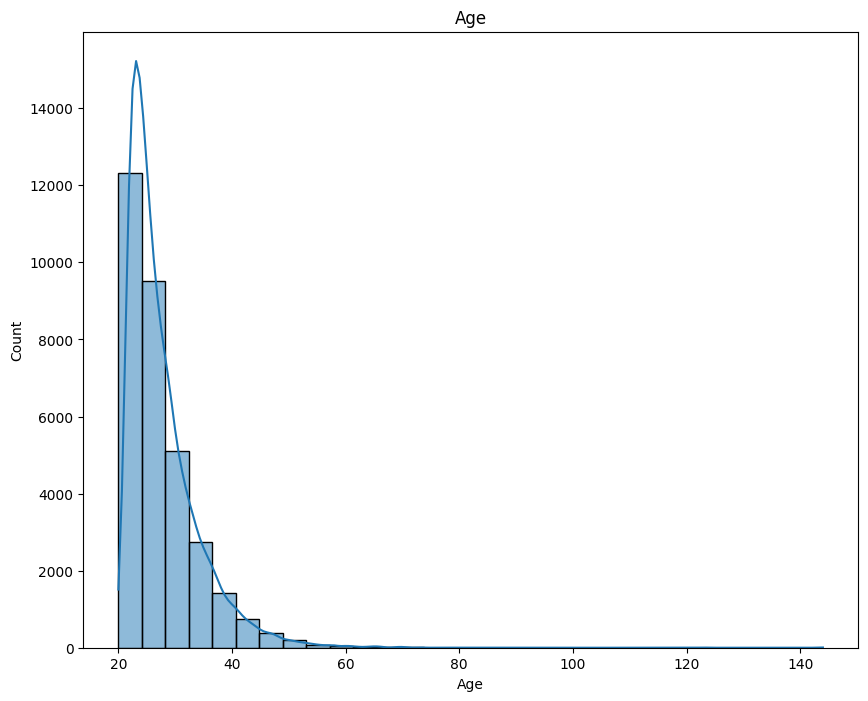

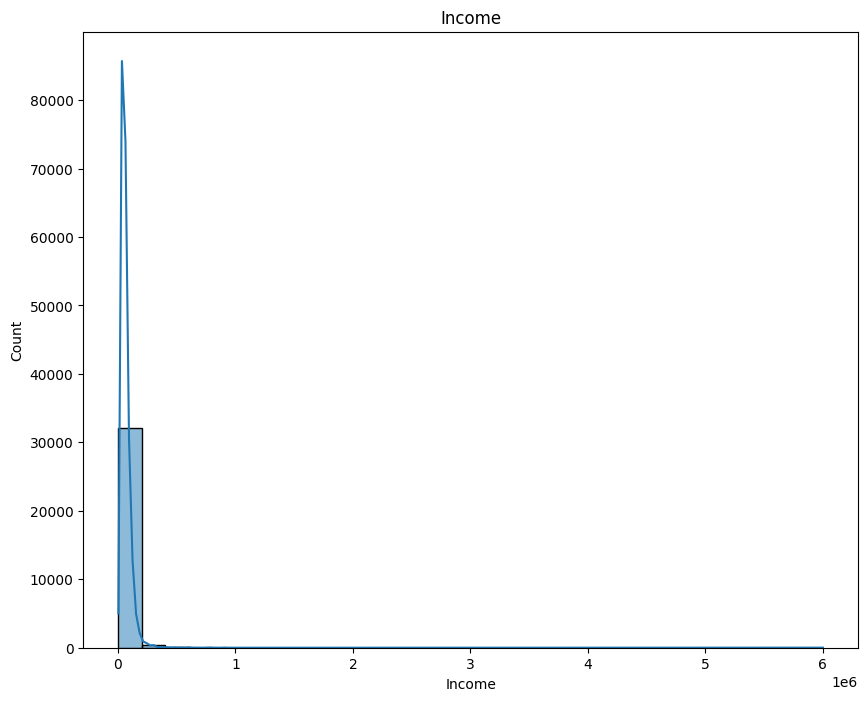

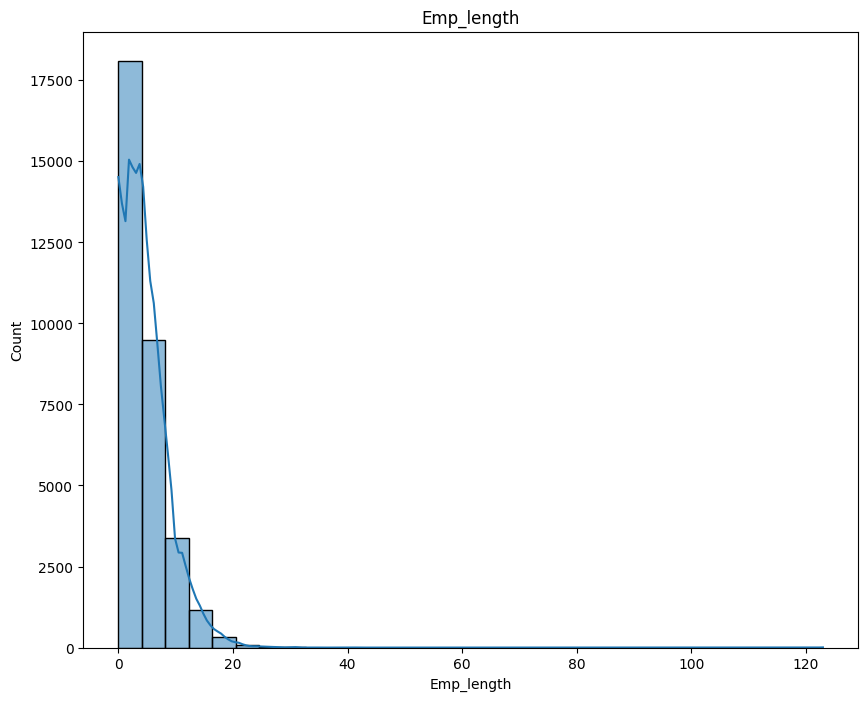

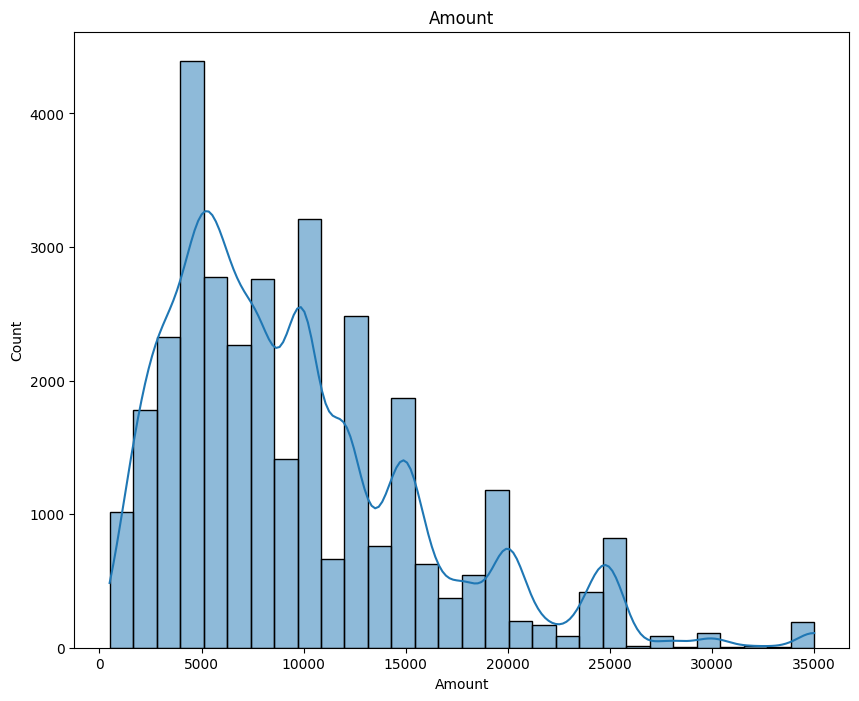

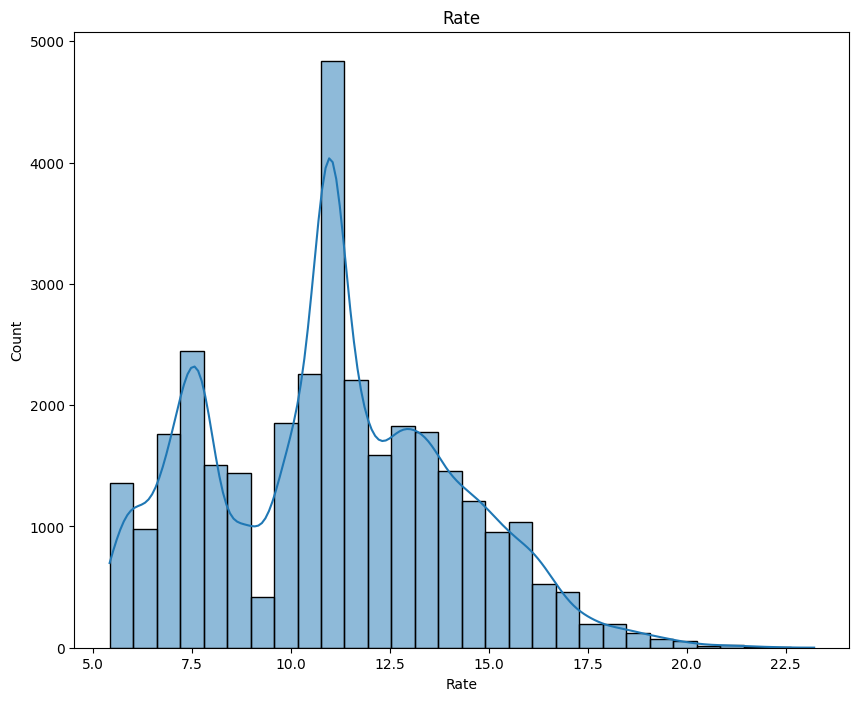

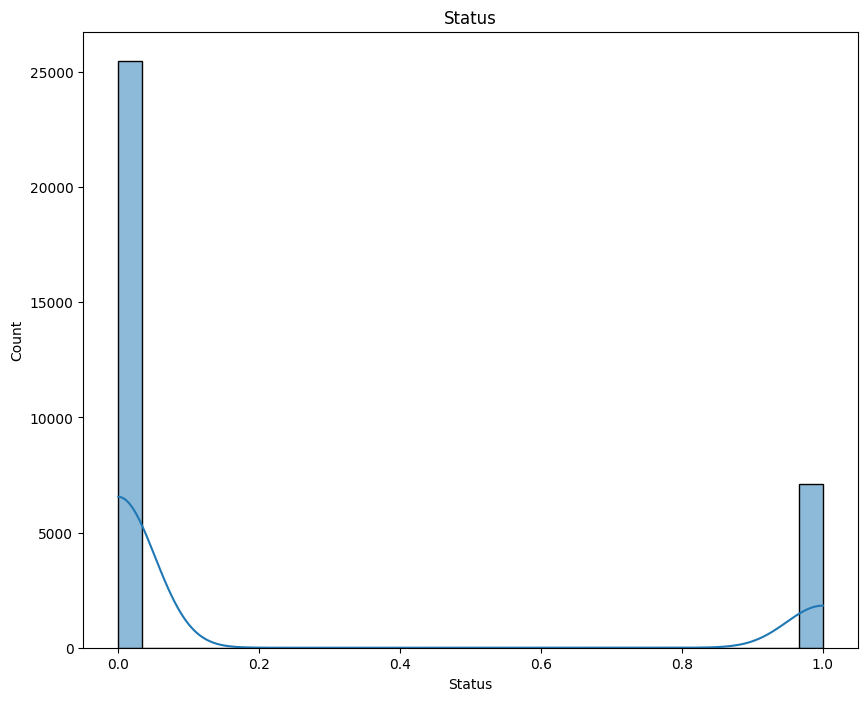

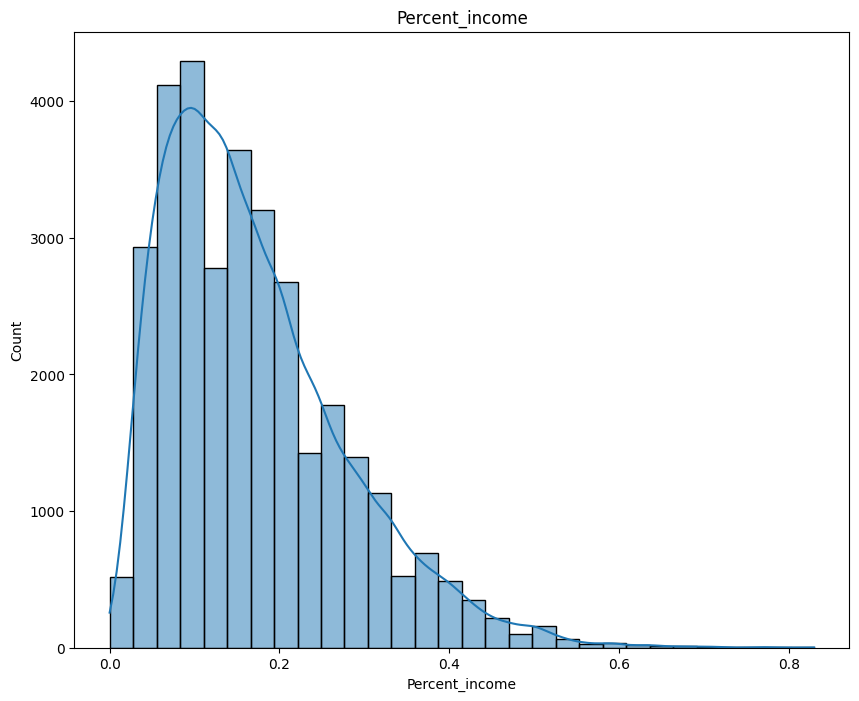

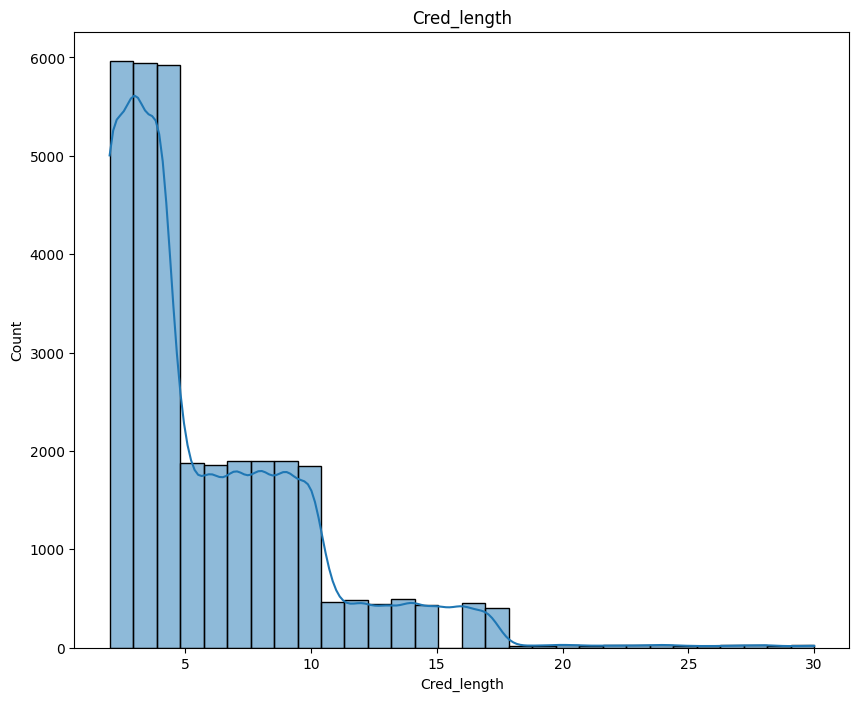

In [21]:
# univariate for numerical columns
for col in num_features:
  plt.figure(figsize= (10,8))
  sns.histplot(df[col], bins = 30, kde = True)
  plt.title(col)
  plt.show()

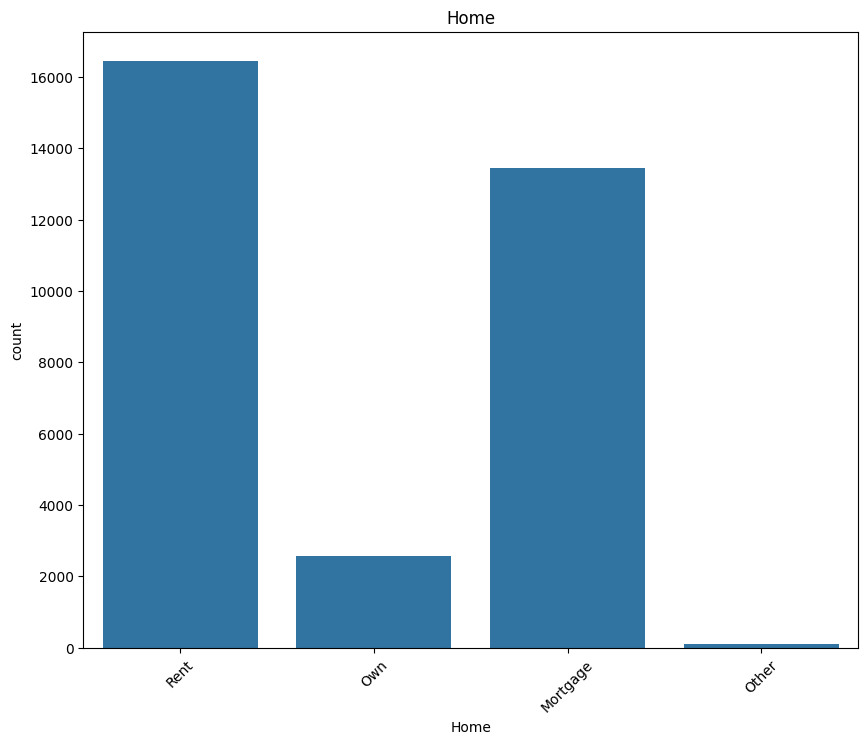

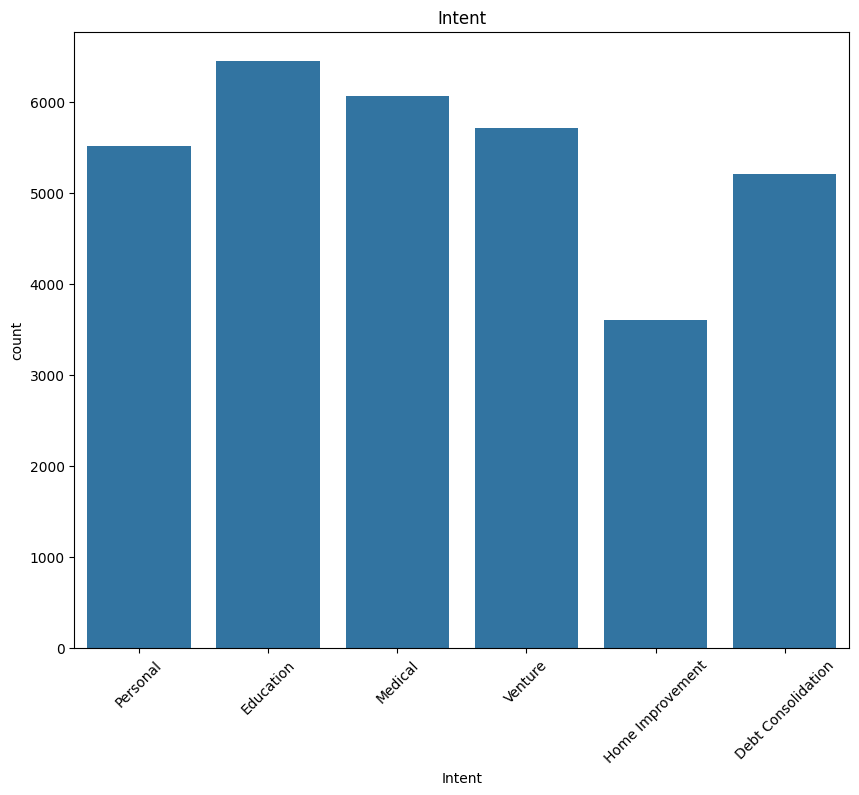

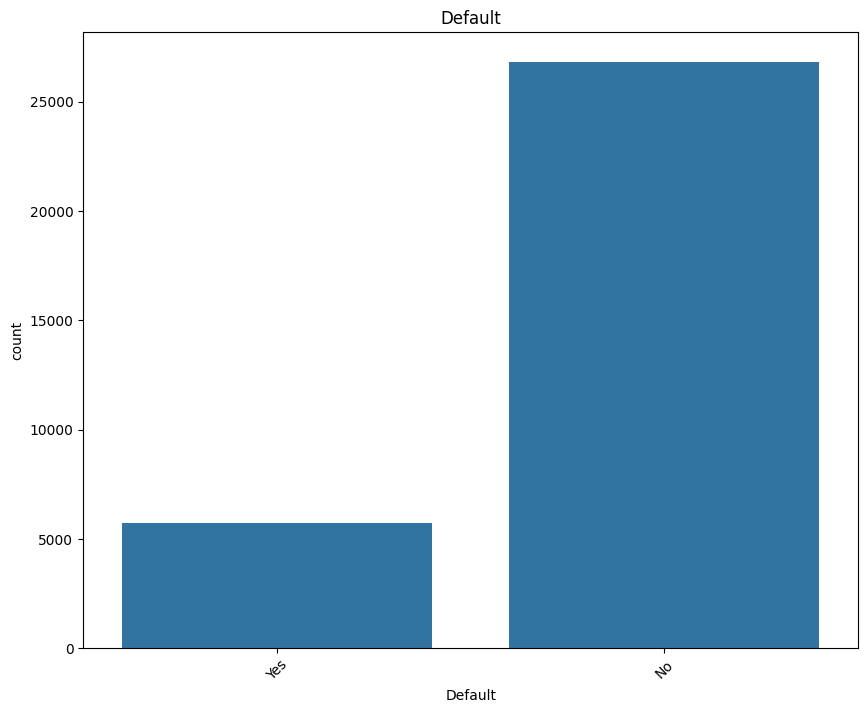

In [22]:
# univariate for categorical columns
for col in cat_features:
  plt.figure(figsize= (10,8))
  sns.countplot(x = df[col])
  plt.title(col)
  plt.xticks(rotation = 45)
  plt.show()

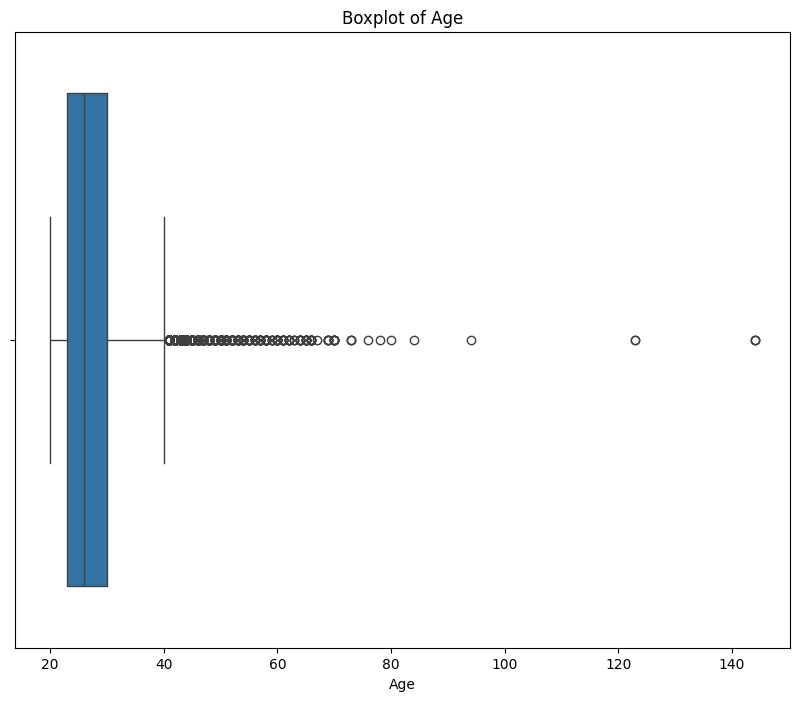

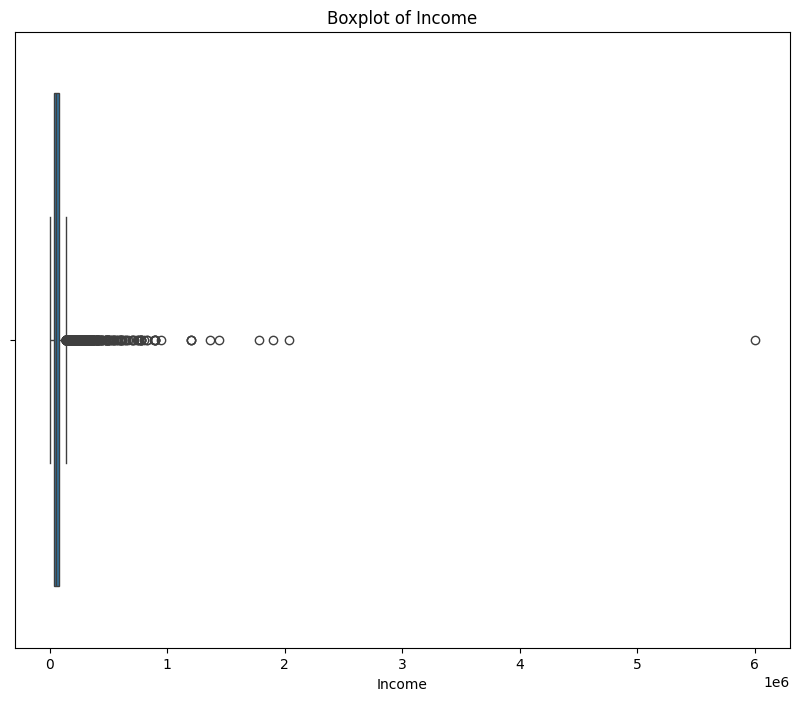

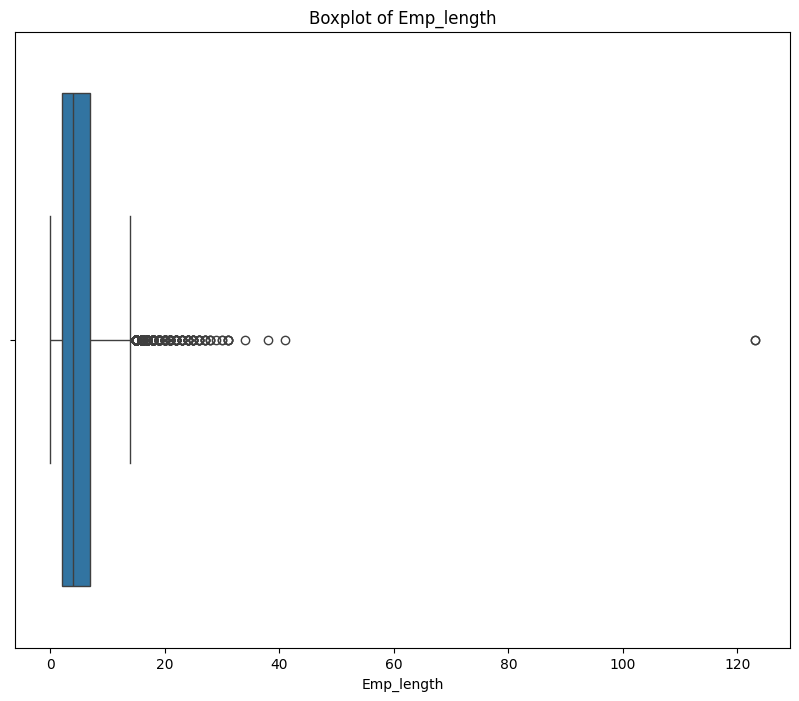

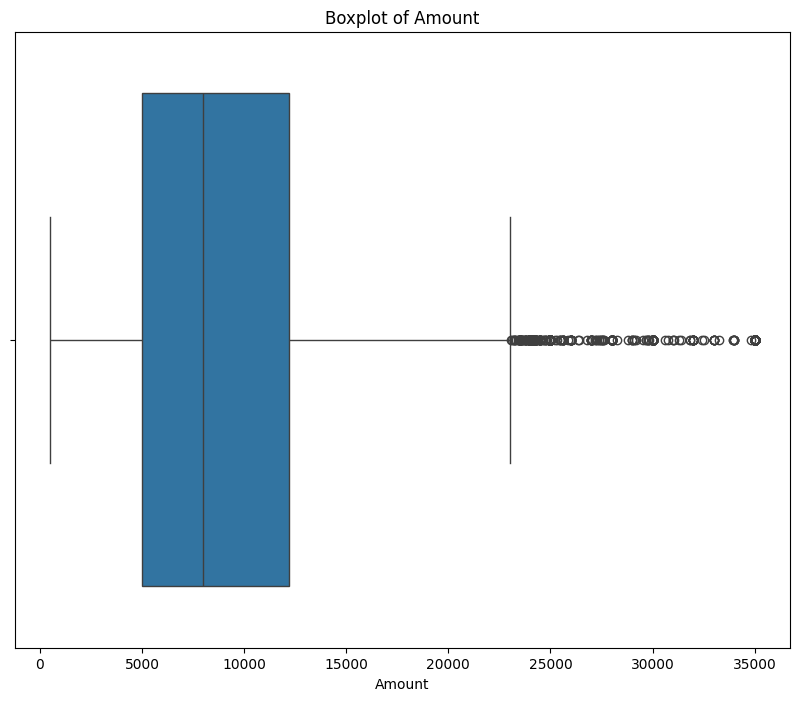

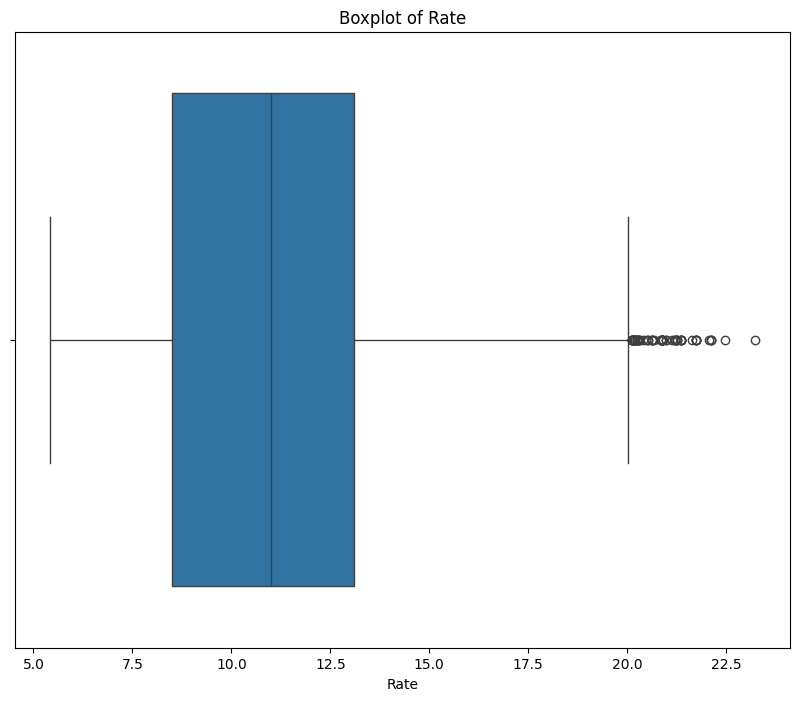

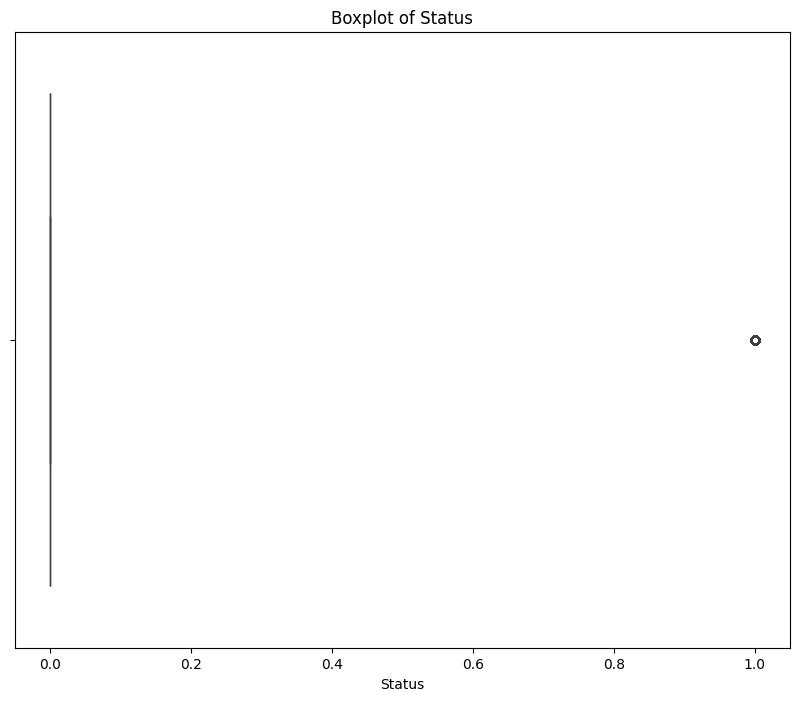

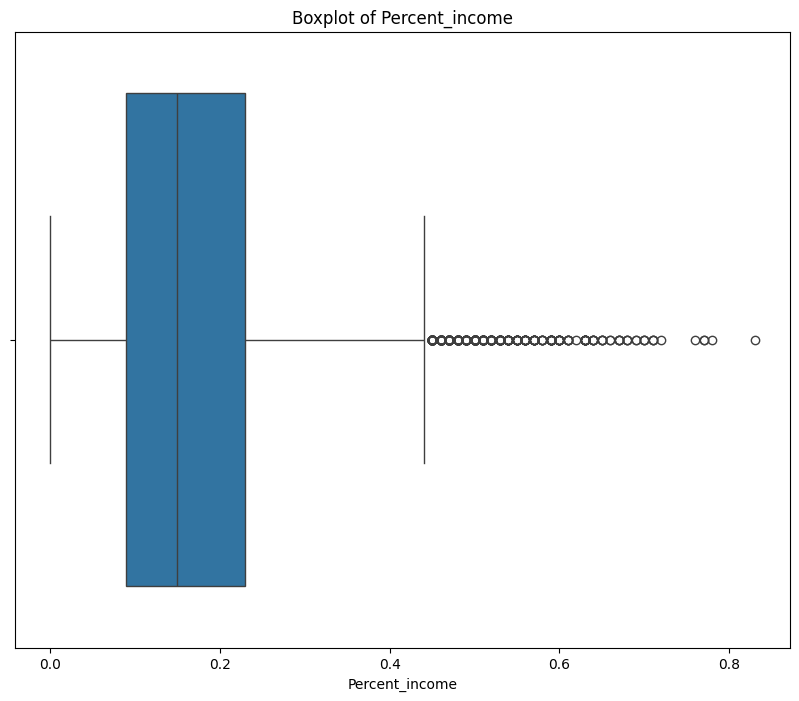

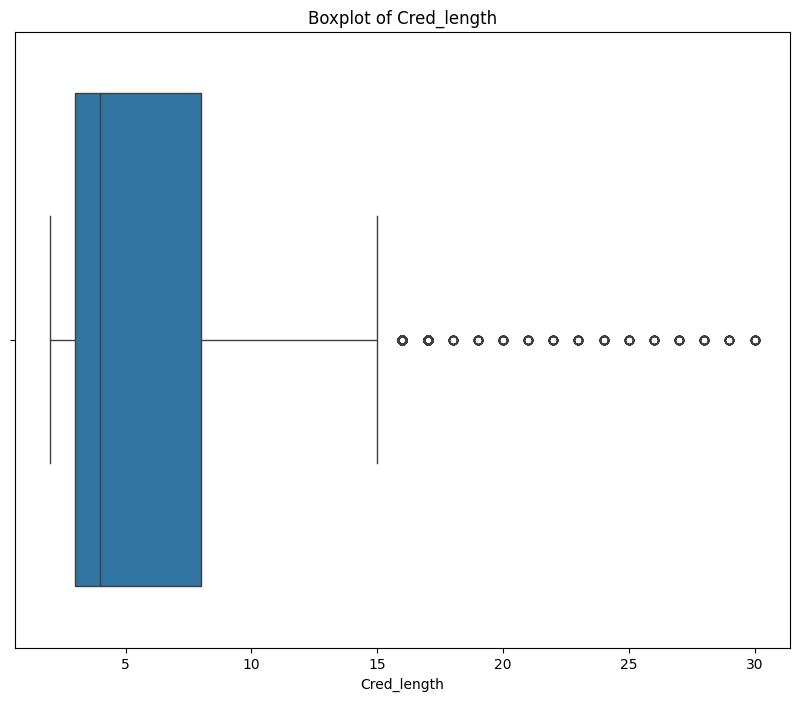

In [23]:
# Univariate analysis (Boxplot)
for col in num_features:
  plt.figure(figsize= (10,8))
  sns.boxplot(x = df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

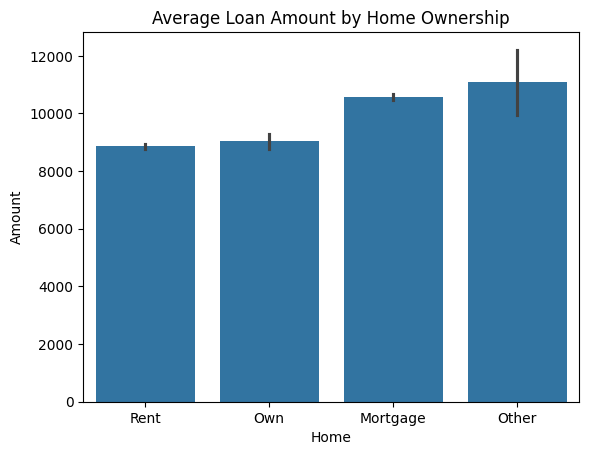

In [24]:
# Bivariate Analysis
sns.barplot(data = df, x = 'Home',y = 'Amount')
plt.title("Average Loan Amount by Home Ownership")
plt.show()

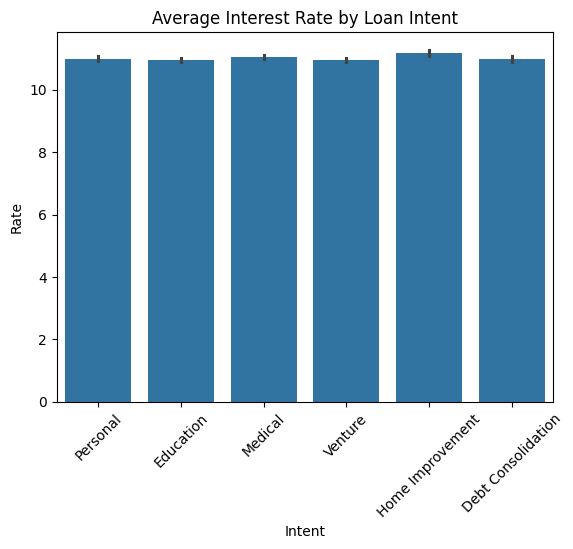

In [25]:
# Average Interest Rate by Loan Intent
sns.barplot(data=df, x='Intent', y='Rate')

plt.title("Average Interest Rate by Loan Intent")
plt.xticks(rotation=45)
plt.show()

**Insight**

The plot shows the interest rate are stable across all loan intents.

In [26]:
df['Amount'].max()

35000

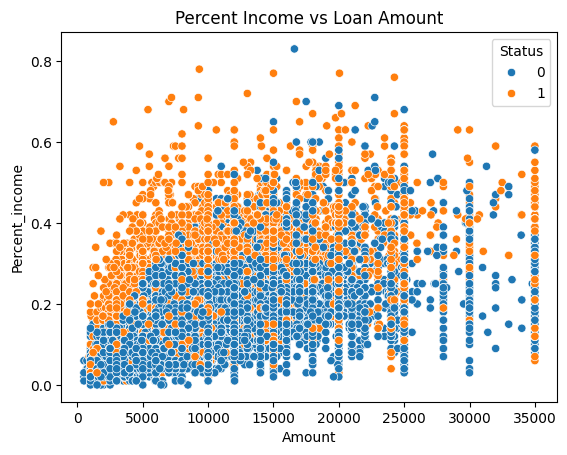

In [27]:
# Bivariate analysis (scatterplot)
sns.scatterplot(data=df, x = 'Amount',y = 'Percent_income', hue = 'Status')
plt.title("Percent Income vs Loan Amount")
plt.show()

**Insight**
The applicant with higher percent income are more oftn associated with status 1, which represents default or high credit risk class.

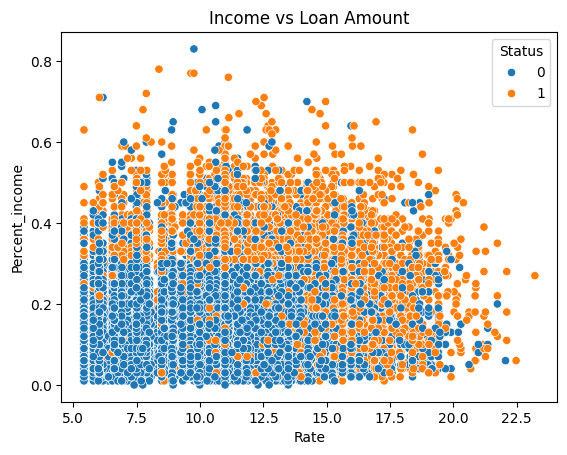

In [28]:
# Bivariate analysis (scatterplot)
sns.scatterplot(data=df, x = 'Rate',y = 'Percent_income', hue = 'Status')
plt.title("Income vs Loan Amount")
plt.show()

Insight
Borrower with Higher rate and higher percent_income are representing default or high credit risk cases.

<Axes: >

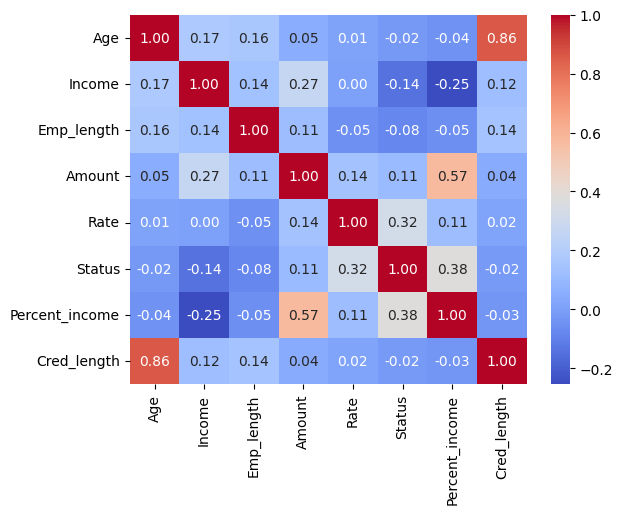

In [29]:
# Multivariate analysis
corr_matrix = df.corr(numeric_only= True)

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')

**Observation**
- Percent_income has the highest positive correlation with Status(target) variable (0.38).
- Rate shows moderate positive correlation with the target variable (0.32).
- Income has a weak negative correlation(-0.14) with Status.
- Amount has a weak positive correlation (0.11) with the target.

Insights
- Applicants with higher percent_income belong to the credit risk class.
- High interest rate have chances of increasing credit risk.
- Age and cred_length have a strong positive correlation, which suggests older applicants usually have longer credit risk.


In [30]:
# duplicate handling
df.duplicated().sum()

np.int64(165)

In [31]:
df = df.drop_duplicates()

In [32]:
(df['Income'] >= 60000).sum()

np.int64(14834)

In [33]:
df[num_features].max()

,0
Age,144.00
Income,6000000.00
Emp_length,123.00
Amount,35000.00
Rate,23.22
Status,1.00
Percent_income,0.83
Cred_length,30.00


In [34]:
# Remove the unrealistic ages
df = df[df['Age'] <= 100]

In [35]:
# Remove unrealistic employment lengths
df = df[df['Emp_length'] <= 50]

In [36]:
# outlier detection in Income column
q1 = df['Income'].quantile(0.25)
q3 = df['Income'].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

df['Income'] = df['Income'].clip(lower_limit, upper_limit)

In [37]:
# outlier detection using IQR method
for col in num_features:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)

  iqr = q3 - q1

  lower_limit = q1 - 1.5 * iqr
  upper_limit = q3 + 1.5 * iqr

  outlier = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

  print(f"{col}: {len(outlier)} outliers")

Age: 1486 outliers
Income: 0 outliers
Emp_length: 850 outliers
Amount: 1678 outliers
Rate: 70 outliers
Status: 7088 outliers
Percent_income: 649 outliers
Cred_length: 1138 outliers


In [38]:
# Separate features and target variable
X = df.drop('Status', axis=1)
y = df['Status']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (32409, 10)
Target Shape: (32409,)


In [39]:
X.head()

,Age,Income,Home,Emp_length,Intent,Amount,Rate,Percent_income,Default,Cred_length
1,21,9600,Own,5.0,Education,1000,11.14,0.10,No,2
2,25,9600,Mortgage,1.0,Medical,5500,12.87,0.57,No,3
3,23,65500,Rent,4.0,Medical,35000,15.23,0.53,No,2
4,24,54400,Rent,8.0,Medical,35000,14.27,0.55,Yes,4
5,21,9900,Own,2.0,Venture,2500,7.14,0.25,No,2


In [40]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state= 42, stratify = y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(25927, 10)
(6482, 10)
(25927,)
(6482,)


In [41]:
num_cols = X_train. select_dtypes(include=['int64', 'float64' ]).columns
cat_cols = X_train. select_dtypes(include=[ 'object' ]). columns

In [42]:
num_features

Index(['Age', 'Income', 'Emp_length', 'Amount', 'Rate', 'Status',
       'Percent_income', 'Cred_length'],
      dtype='object')

# **Data Preprocessing**

In [43]:
# Encoding Techniques And Feature Scaling
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers= [
                                               ("cat",OneHotEncoder(handle_unknown='ignore', sparse_output= False),cat_cols),
                                               ("num", RobustScaler(),num_cols)
                                               ],
                                 remainder='passthrough'

                                 )

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)


print(X_train_trans.shape)
print(X_test_trans.shape)

(25927, 19)
(6482, 19)


In [44]:
print(y_train.value_counts())

print(y_train.value_counts(normalize=True) * 100)

Status
0    20257
1     5670
Name: count, dtype: int64
Status
0    78.130906
1    21.869094
Name: proportion, dtype: float64


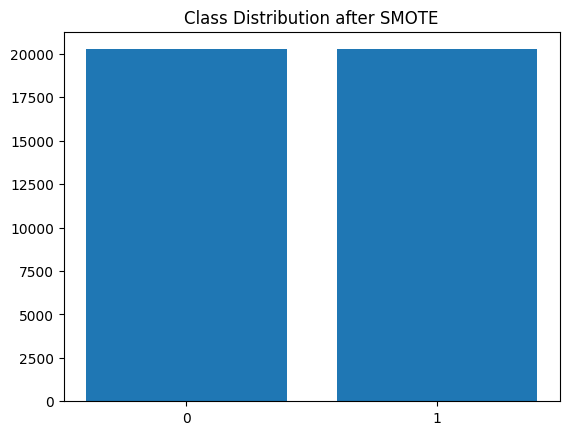

Status
0    20257
1    20257
Name: count, dtype: int64


In [45]:
# HAndling Imbalanced data using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy= 'minority', random_state= 42)
X_train_sm , y_train_sm = smote.fit_resample(X_train_trans, y_train)

counts = y_train_sm.value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Distribution after SMOTE")
plt.show()

print(y_train_sm.value_counts())


# **Feature Selection**

In [46]:
  # Mutual classifier
from sklearn.feature_selection import mutual_info_classif

mic = mutual_info_classif(X_train_sm, y_train_sm, random_state = 42)

mic_df = pd.DataFrame({
    'Feature': preprocessor.get_feature_names_out(),
    'MI Score': mic
})

In [47]:
mic_df = mic_df.sort_values('MI Score', ascending = False)

In [48]:
# select the top 10 features
from sklearn.feature_selection import SelectKBest

top_10 = SelectKBest(score_func = mutual_info_classif, k= 10)

X_train_top10 = top_10.fit_transform(X_train_sm, y_train_sm)
X_test_top10 = top_10.transform(X_test_trans)

selected_features = preprocessor.get_feature_names_out()[top_10.get_support()]
print(selected_features)

['cat__Home_Mortgage' 'cat__Home_Rent' 'cat__Default_Yes' 'num__Age'
 'num__Income' 'num__Emp_length' 'num__Amount' 'num__Rate'
 'num__Percent_income' 'num__Cred_length']


# **Hyperparameter Tuning and Model Building**

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
# Logistic Regression Classifier model
lr = LogisticRegression(random_state=42, max_iter = 1000)

param_grid = {
    'penalty': ['l1','l2'],
     'C': [0.01, 0.1,1,10,100],
     'solver': ['liblinear']


}
grid_lr = GridSearchCV(estimator= lr,
                       param_grid = param_grid,
                       cv = 5,
                       scoring = 'accuracy',
                       n_jobs = -1)

grid_lr.fit(X_train_top10, y_train_sm)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV SCore:", grid_lr.best_score_)

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV SCore: 0.7672409409913763


In [50]:
# Decision Tree Classifier model
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]

}

grid_dt = GridSearchCV(estimator = dt,
                       param_grid = param_grid,
                       cv = 5,
                       scoring= 'accuracy',
                       n_jobs = -1)

grid_dt.fit(X_train_top10, y_train_sm)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV SCore:", grid_dt.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV SCore: 0.8533598324436372


In [51]:
from sklearn.neighbors import KNeighborsClassifier

# KNeighbors Classifier model
knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3,5,7,9,11],
    "weights": ['uniform','distance'],
    "metric": ['euclidean','manhattan','minkowski']
}

grid_knn = GridSearchCV(estimator = knn,
                        param_grid = param_grid,
                        cv = 5,
                        scoring = 'accuracy',
                        n_jobs = -1)

grid_knn.fit(X_train_top10, y_train_sm)

print("Best Parameters:", grid_knn.best_params_)
print("Best CV SCore:", grid_knn.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV SCore: 0.8875698140087451


In [52]:
# Decision Tree Classifier model
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]

}

grid_dt = GridSearchCV(estimator = dt,
                       param_grid = param_grid,
                       cv = 5,
                       scoring= 'accuracy',
                       n_jobs = -1)

grid_dt.fit(X_train_top10, y_train_sm)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV SCore:", grid_dt.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV SCore: 0.8533598324436372


# **Model Evaluation**

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


# best mode
lr_best = grid_lr.best_estimator_
dt_best = grid_dt.best_estimator_
knn_best = grid_knn.best_estimator_

# collect al the models
models = {
    "Logistic Regtressio": lr_best,
    "Decision Tree": dt_best,
    "KNN": knn_best,
}

# Evaluate the model on test set
results = []

for name, model in models.items():
  y_pred = model.predict(X_test_top10)
  y_prob = model.predict_proba(X_test_top10)[:, 1]

  results.append({
      "Model": name,
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred),
      "Recall": recall_score(y_test, y_pred),
      "F1 Score": f1_score(y_test, y_pred),
      "ROC-AUC": roc_auc_score(y_test, y_prob)
  })


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix",cm)

results_df = pd.DataFrame(results).sort_values(by = 'Accuracy', ascending = False)
print(results_df)

Confusion Matrix [[4294  770]
 [ 408 1010]]
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1        Decision Tree  0.833693   0.600118  0.718618  0.654044  0.792239
2                  KNN  0.818266   0.567416  0.712271  0.631645  0.837031
0  Logistic Regtressio  0.769670   0.483444  0.772214  0.594624  0.841908


- From the above Model is Best Performing Model is Decision Tree.
- It achieved 84% Accuracy and also high precision recall and F1 score

# **Model Interpretation**

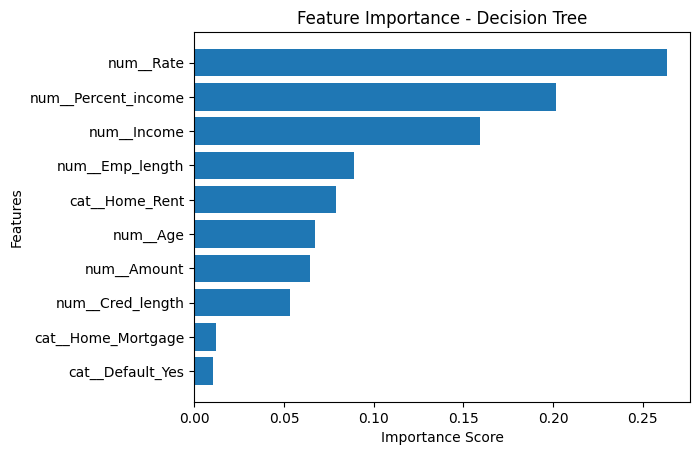

In [54]:
# Feature Importance

importance = dt_best.feature_importances_

feature_names = selected_features

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(by = 'Importance')

# plot feature importance
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Decision Tree")
plt.show()

# **Save the Model**

In [55]:
import joblib
from sklearn.pipeline import Pipeline

In [56]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", top_10),
    ("classifier", dt_best)
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [57]:
! pip install Streamlit

In [58]:
# load the saved file
import streamlit
model = joblib.load("credit_risk_model.pkl")

In [59]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['Home', 'Intent', 'Default'], dtype='object')),
                                                 ('num', RobustScaler(),
                                                  Index(['Age', 'Income', 'Emp_length', 'Amount', 'Rate', 'Percent_income',
       'Cred_length'],
      dtype='object'))])),
                ('selector',
                 SelectKBest(score_func=<function mutual_info_classif at 0x7e4f9a835260>)),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', random_state=42))])